# Graph Isomorphism

***

In [3]:
# Plots.
import matplotlib.pyplot as plt

In [4]:
# Resize plots.
plt.rcParams['figure.figsize'] = (6, 6)

In [5]:
# Matrices.
import numpy as np

In [6]:
# Permutations
import itertools as it

In [7]:
# Graphs.
import networkx as nx

In [8]:
# Math.
import math

In [9]:
# Networkx drawing parameters.
params = {'node_color': 'lightskyblue', 'node_size': 800, 'font_size': 18, 'with_labels': True}

<br>

## Graphs

***

In [10]:
# Create an empty graph.
G = nx.Graph()

In [11]:
# Create a set of edges.
# Note that ideally this would be written as {{0, 1}, {1, 2}, {0, 2}}.
# E should be a set of two-subsets of a finite set V (which is defined implicitly from E).
E = ((0, 1), (1, 2), (0, 2))

In [12]:
# Incorporate the edges in G.
# The nodes are just created as needed, based on E.
G.add_edges_from(E)

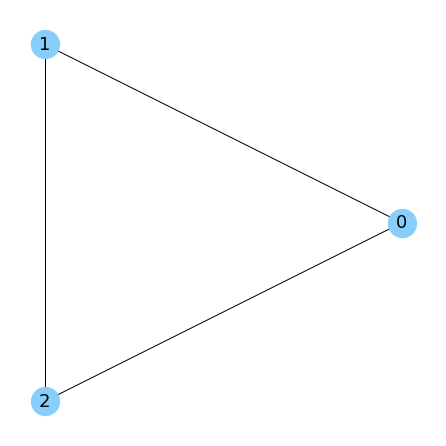

In [13]:
# Draw G.
nx.draw_circular(G, **params)

<br>

## Adjacency Matrices

***

In [14]:
# The adjacency matrix of G.
print(nx.to_numpy_array(G))

[[0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 0.]]


In [15]:
# Convert it to unsigned 8 bit integers (for no good reason).
A = nx.to_numpy_array(G).astype(np.uint8)
print(A)

[[0 1 1]
 [1 0 1]
 [1 1 0]]


In [16]:
# The transpose of A.
print(A.T)

[[0 1 1]
 [1 0 1]
 [1 1 0]]


In [17]:
# All entries of A and its transpose are the same.
print(A.T == A)

[[ True  True  True]
 [ True  True  True]
 [ True  True  True]]


In [18]:
# all() checks they're all True.
(A.T == A).all()

True

In [19]:
# A slightly cleaner way to print (binary) matrices.
def matrix_print(A):
  # Loop through rows of A.
  for r in A:
    # Print the current row, removing the brackets numpy puts in.
    print(str(r)[1:-1])
  # Print a blank line.
  print()

In [20]:
# Example.
matrix_print(A)

0 1 1
1 0 1
1 1 0



<br>

## Permutations

***

In [21]:
# A list of numbers.
L = list(range(1, 4))
L

[1, 2, 3]

In [22]:
# All permutations of that list.
# Note that it.permutations returns a generator.
# The number of permutations grows very fast compared to the length of the list.
perms = it.permutations(L)
# Print the permutations.
for perm in perms:
  print(perm)

(1, 2, 3)
(1, 3, 2)
(2, 1, 3)
(2, 3, 1)
(3, 1, 2)
(3, 2, 1)


## Matrix Multiplication

***

In [23]:
# A matrix for keeping track of operations.
A = np.array([[1, 2], [3, 4]], dtype=np.uint8)
matrix_print(A)

1 2
3 4



In [24]:
# The identity matrix of size two - two rows and two columns.
I = np.identity(2, dtype=np.uint8)
# Exactly one 1 in each row and each column, zeros otherwise.
matrix_print(I)

1 0
0 1



In [25]:
# This does pointwise multiplication in numpy.
matrix_print(A * I) 

1 0
0 4



In [26]:
# This does the usual matrix multiplication.
matrix_print(A @ I) 

1 2
3 4



In [27]:
# The identity matrix leaves A unchanged.
matrix_print(I @ A) 

1 2
3 4



In [28]:
# It also commutes, meaning I @ A == A @ I.
np.all(I @ A == A @ I)

True

In [29]:
# The only other permutation matrix of size 2.
P = np.array([[0, 1], [1, 0]], dtype=np.uint8)
matrix_print(P)

0 1
1 0



In [30]:
# Permute the columns of A.
matrix_print(A @ P)

2 1
4 3



In [31]:
# Compare to A.
matrix_print(A)

1 2
3 4



In [32]:
# Permute the rows of A.
matrix_print(P @ A)

3 4
1 2



In [33]:
# The transpose of P (interchange rows and columns).
matrix_print(P.T)

0 1
1 0



In [34]:
# P and P.T happen to be equal here.
np.all(P == P.T)

True

In [35]:
# Size three.
I = np.identity(3, dtype=np.uint8)
matrix_print(I)

1 0 0
0 1 0
0 0 1



In [36]:
# Using a list for array indexing in numpy.
# Handy for creating permutation matrices.
# Permutation matrices are always row/column permutations of the identity matrix.
P = I[[1, 0, 2]]
matrix_print(P)

0 1 0
1 0 0
0 0 1



In [37]:
# Here is a 3x3 version of A.
A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=np.uint8)
matrix_print(A)

1 2 3
4 5 6
7 8 9



In [38]:
# Permute columns using P.
matrix_print(A @ P)

2 1 3
5 4 6
8 7 9



In [39]:
# Permute rows using P.
matrix_print(P @ A)

4 5 6
1 2 3
7 8 9



In [40]:
# P and P.T are equal again.
np.all(P.T == P)

True

In [41]:
# Let's look at a P that is not equal to it's own transpose.
P = I[[1, 2, 0]]
matrix_print(P)

0 1 0
0 0 1
1 0 0



In [42]:
# Not equal.
np.all(P == P.T)

False

In [43]:
# Permute the columns.
# Note the columns move forwards - towards the right.
matrix_print(A @ P)

3 1 2
6 4 5
9 7 8



In [44]:
# Permute the columns with P.T.
# Note the columns move backwards - towards the left.
matrix_print(A @ P.T)

2 3 1
5 6 4
8 9 7



In [45]:
# Here's P for reference.
matrix_print(P)

0 1 0
0 0 1
1 0 0



In [46]:
# Here's its transpose.
matrix_print(P.T)

0 0 1
1 0 0
0 1 0



In [47]:
# Here's A again for reference.
matrix_print(A)

1 2 3
4 5 6
7 8 9



In [48]:
# Permute the rows of A.
# Notice they move backwards - towards the top of the matrix.
matrix_print(P @ A)

4 5 6
7 8 9
1 2 3



In [49]:
# To get the equivalent row permutation as column permutation, you need P transpose.
# Note by equivalent I mean the rows/columns moving forwards, where forward
# means down for rows and right for columns.
matrix_print(P.T @ A)

7 8 9
1 2 3
4 5 6



<br>

## Permutation Matrices

***

In [50]:
# Number of objects to permute.
N = 3

In [51]:
# Identity matrix.
I = np.identity(N, dtype=np.uint8)
matrix_print(I)

1 0 0
0 1 0
0 0 1



In [53]:
# Permutations of rows of I.
perms = it.permutations(range(N))
# Print I with rows permuted by p.
for p in perms:
  # Permutation matrix - using numpy indexing.
  Pmat = I[list(p)]
  matrix_print(Pmat)

1 0 0
0 1 0
0 0 1

1 0 0
0 0 1
0 1 0

0 1 0
1 0 0
0 0 1

0 1 0
0 0 1
1 0 0

0 0 1
1 0 0
0 1 0

0 0 1
0 1 0
1 0 0



In [55]:
L = np.array(range(1, N+1), dtype=np.uint8)
L

array([1, 2, 3], dtype=uint8)

In [56]:
perms = it.permutations(range(N))
for p in perms:
    Pmat = I[list(p)]
    
    Lp = L @ Pmat
    print(Lp)

[1 2 3]
[1 3 2]
[2 1 3]
[3 1 2]
[2 3 1]
[3 2 1]


In [57]:
#3x3 version of A
A = np.array([[1,2,3], [4,5,6],[7,8,9]], dtype = np.uint8)
matrix_print(A)

1 2 3
4 5 6
7 8 9



In [61]:
perms = it.permutations(range(N))
for p in perms:
    Pmat = I[list(p)]
    Ap = Pmat @ A @ Pmat.T
    matrix_print(Ap)

1 2 3
4 5 6
7 8 9

1 3 2
7 9 8
4 6 5

5 4 6
2 1 3
8 7 9

5 6 4
8 9 7
2 3 1

9 7 8
3 1 2
6 4 5

9 8 7
6 5 4
3 2 1



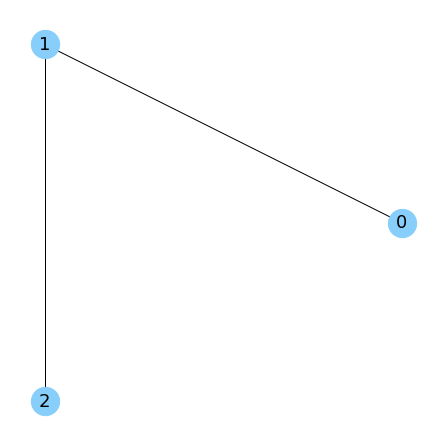

In [63]:
#Making a graph from adjancey graph
G = nx.Graph()
E = ((0,1), (1,2))
G.add_edges_from(E)
nx.draw_circular(G, **params)

In [66]:
A = nx.to_numpy_array(G).astype(np.uint8)
matrix_print(A)

0 1 0
1 0 1
0 1 0



In [69]:
perms = it.permutations(range(N))

for p in perms:
    Pmat = I[list(p)]
    Ap = Pmat @ A @ Pmat.T
    matrix_print(Ap)

0 1 0
1 0 1
0 1 0

0 0 1
0 0 1
1 1 0

0 1 1
1 0 0
1 0 0

0 1 1
1 0 0
1 0 0

0 0 1
0 0 1
1 1 0

0 1 0
1 0 1
0 1 0

